# Demonstration of rotationally symmetric SVD decomposition in Panther-EM.

1. Download and simulate cryo-EM projections of a structure
2. Perform optimized SVD decomposition by exploiting in-plane rotational symmetry (in polar coordinates)
3. Plot singular values of the decomposition
4. Plot polar/cartesian features of decomposition

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch_so3 import get_uniform_euler_angles
from ttsim3d.models import Simulator, SimulatorConfig

from panther_em.decomposition import PolarProjectionDecomposer
from panther_em.inference.projection_reconstruction import ProjectionReconstructor
from panther_em.inference.correlation import compute_correlogram

## Load in volume to take projections from

In [2]:
!wget -nc https://files.rcsb.org/download/pdb_00001dpo.cif

File ‘pdb_00001dpo.cif’ already there; not retrieving.



In [3]:
from simulate_volume import simulate_volume

# def simulate_volume(
#     pdb_path: str,
#     pixel_spacing: float = 0.4,
#     volume_shape: tuple[int, int, int] = (256, 256, 256),
#     voltage: float = 300.0,
#     dose_start: float = 0.0,
#     dose_end: float = 15.0,
#     b_factor_scaling: float = 1.0,
#     additional_b_factor: float = 30.0,
# )

In [4]:
volume = simulate_volume(
    pdb_path="pdb_00001dpo.cif",
    pixel_spacing=0.4,
    volume_shape=(256, 256, 256),
    voltage=300.0,
    dose_start=0.0,
    dose_end=15.0,
    b_factor_scaling=1.0,
    additional_b_factor=30.0,
)

In [5]:
type(volume), volume.shape, volume.dtype

(numpy.ndarray, (256, 256, 256), dtype('float32'))

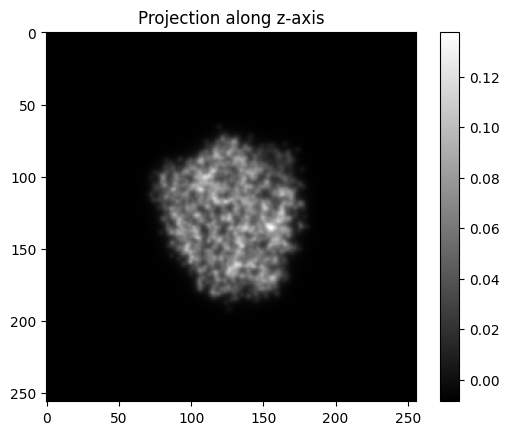

In [6]:
plt.imshow(volume.sum(axis=0), cmap="gray")
plt.title("Projection along z-axis")
plt.colorbar()
plt.show()

## Define the out-of-plane orientations

Using `torch-so3` to approximate points over SO(3) space, except all in-plane angles are set to zero.

In [7]:
angles = get_uniform_euler_angles(psi_step=360.0, theta_step=6.0)
print(angles.shape)

phi_angles = angles[:, 0].numpy()
theta_angles = angles[:, 1].numpy()

torch.Size([1148, 3])


## Run the decomposition

In [8]:
radial_components = 256
angular_components = 360

k_max = 240
eig_max = 128

decomposer = PolarProjectionDecomposer(
    volume=volume,
    phi_values=phi_angles,
    theta_values=theta_angles,
    num_radius=radial_components,
    num_angle=angular_components,
    device="cuda",
)

result = decomposer.do_decomposition(k_max=k_max, eig_max=eig_max)

decomp freq blocks: 100%|██████████| 30/30 [00:02<00:00, 11.49it/s]


In [9]:
result

DecompositionResult(
    k_max=240,
    eig_max=128,
    num_fourier_filters=1,
    num_orientations=1148,
    num_angular_components=360,
    num_radial_components=256,
    created_at='2026-04-22T15:07:45.397999'
)

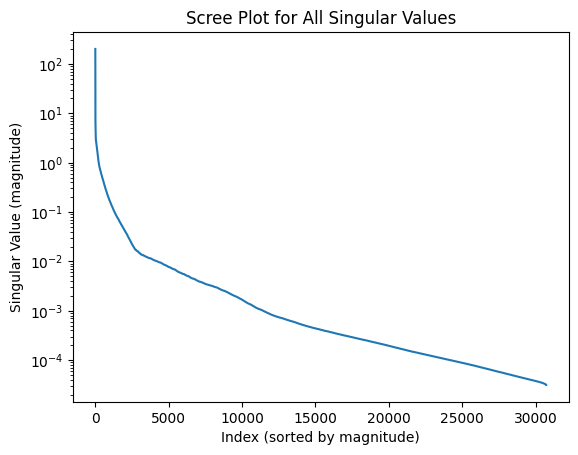

In [10]:
fix, ax = result.scree_plot()
plt.yscale("log")

## Visualize real/imag feature components in polar and cartesian space

In [11]:
reconstructor = ProjectionReconstructor(
    result=result,
    image_shape=(volume.shape[-2], volume.shape[-1]),
    device="cuda",
)

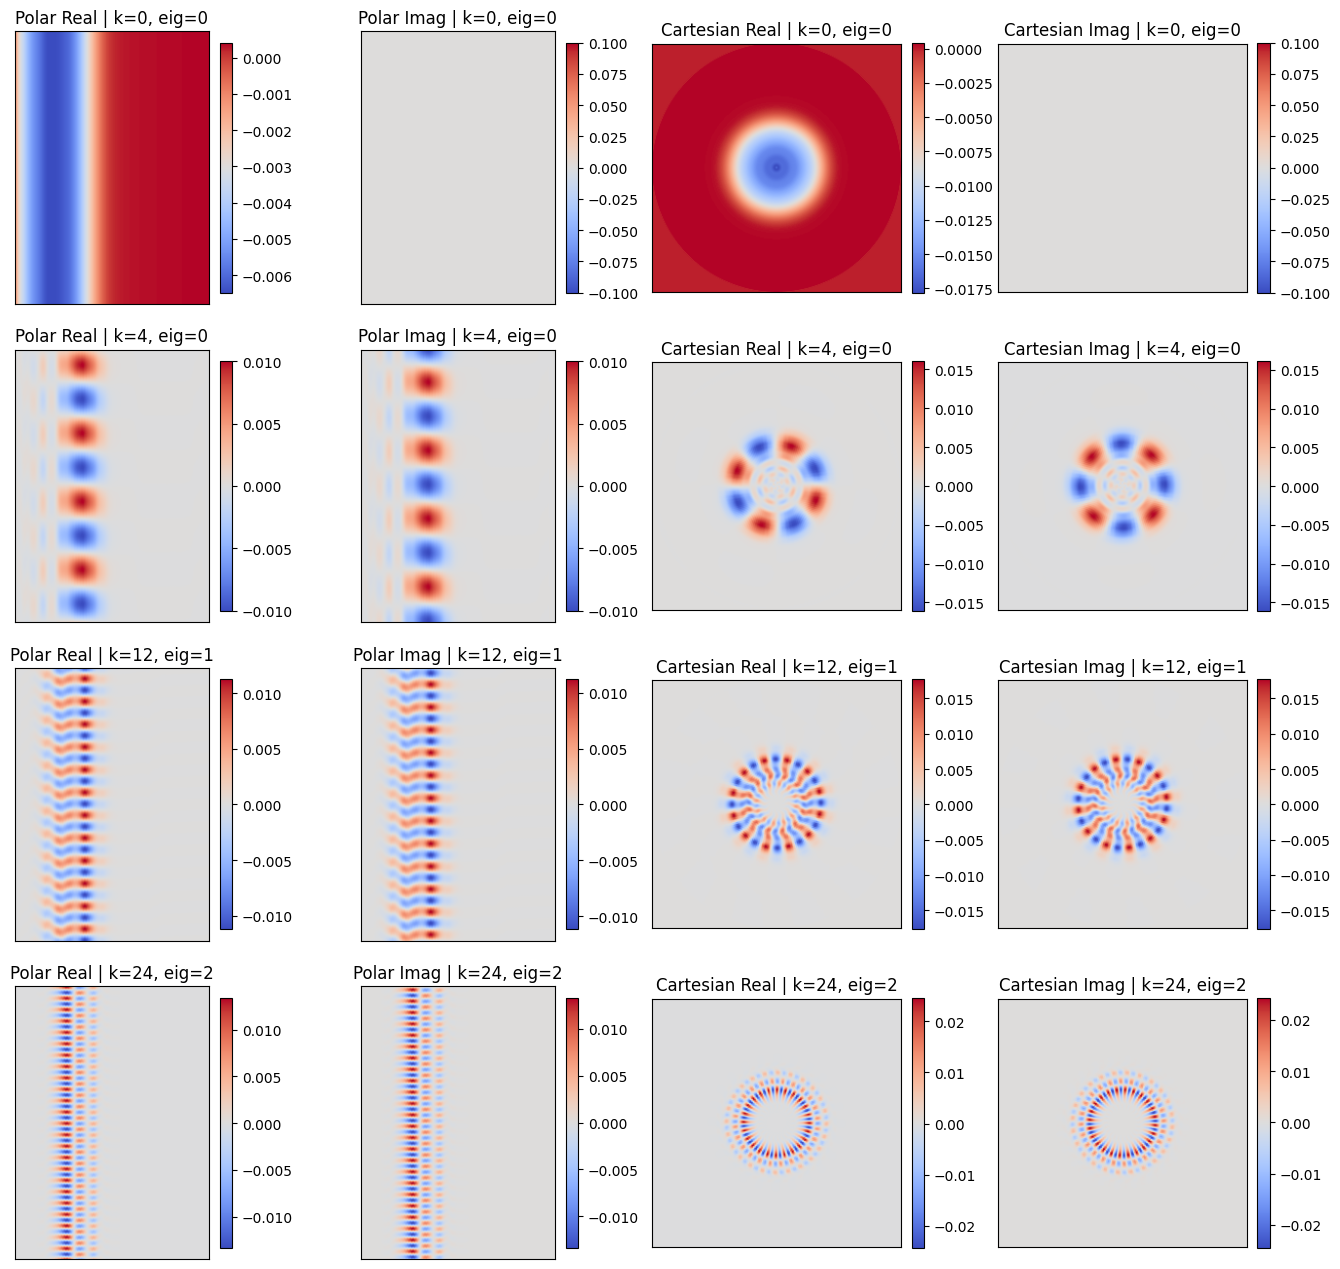

In [12]:
# Pick a few (k_idx, eig_idx) feature pairs to inspect
feature_pairs = [(0, 0), (4, 0), (12, 1), (24, 2)]

n = len(feature_pairs)
fig, axes = plt.subplots(n, 4, figsize=(14, 3.2 * n), squeeze=False)

for row, (k_idx, eig_idx) in enumerate(feature_pairs):
    polar_feature = reconstructor.construct_polar_feature(k_idx=k_idx, eig_idx=eig_idx)
    cart_feature = reconstructor.construct_cartesian_feature(
        k_idx=k_idx, eig_idx=eig_idx
    )

    panels = [
        (np.real(polar_feature), "Polar Real"),
        (np.imag(polar_feature), "Polar Imag"),
        (np.real(cart_feature), "Cartesian Real"),
        (np.imag(cart_feature), "Cartesian Imag"),
    ]

    for col, (img, title) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(img, cmap="coolwarm")
        ax.set_title(f"{title} | k={k_idx}, eig={eig_idx}")
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Projection reconstructions up to a certain rank

In [13]:
reconstructor = ProjectionReconstructor(
    result=result,
    image_shape=(volume.shape[-2], volume.shape[-1]),
    device="cuda",
)

In [14]:
ranks = [4, 16, 64, 256, 1024, 4096]
reconstructions = []

for r in ranks:
    recon = reconstructor.reconstruct_projection(
        orientation_idx=0,
        fourier_filter_idx=0,
        num_components=r,
        return_polar=False,
        return_torch=False,
    )
    reconstructions.append(recon)

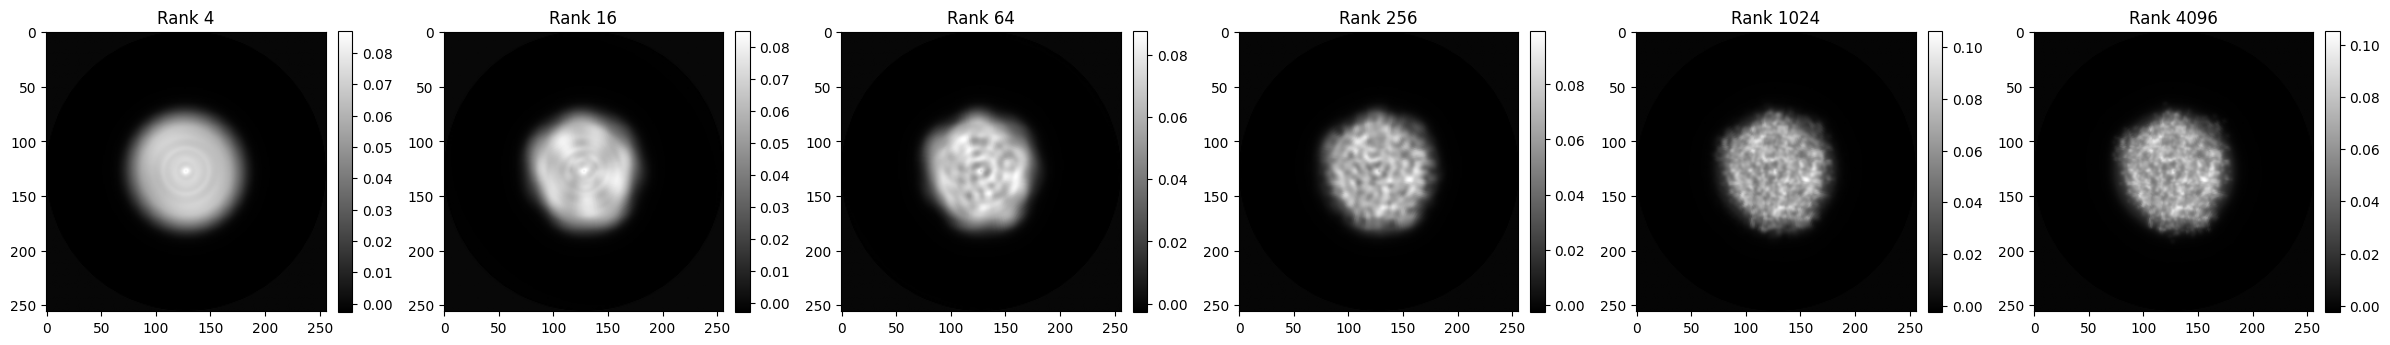

In [15]:
# Plot the reconstructions
fig, axes = plt.subplots(1, len(ranks), figsize=(4 * len(ranks), 4))

for ax, recon, r in zip(axes, reconstructions, ranks):
    im = ax.imshow(recon.real, cmap="gray")
    ax.set_title(f"Rank {r}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [16]:
print("left-singular-vectors shape:                  ", result.U.shape)
print("singular-values shape:                        ", result.S.shape)
print("right-singular-vectors (conj transpose) shape:", result.Vh.shape)

left-singular-vectors shape:                   (1, 1148, 240, 128)
singular-values shape:                         (240, 128)
right-singular-vectors (conj transpose) shape: (240, 128, 256)
